<a href="https://colab.research.google.com/github/anh-tgmt/DL/blob/main/hocsau.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#I, Cài đặt thư viện và kết nối Google Drive

In [ ]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import drive
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Kết nối Drive
drive.mount('/content/drive')

# Thiết lập đường dẫn
save_path = "/content/drive/MyDrive/HocSau_MobileNet/"
if not os.path.exists(save_path):
    os.makedirs(save_path)

Mounted at /content/drive


#II, Làm sạch dữ liệu

Với mô hình MobileNetV2 chúng ta sẽ phải sử dụng phương pháp làm mượt (Smoothing) để mô hình ResNet50 không quá tự tin sai lầm, giúp tăng Accuracy khi tinh chỉnh.

In [ ]:
print("🚀 Đang tải và xử lý dữ liệu...")
(X_raw, y_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()

# Gộp và chia lại theo tỉ lệ: 70% Train, 15% Val, 15% Test
X_all = np.concatenate([X_raw, X_test_raw])
y_all = np.concatenate([y_raw, y_test_raw])

X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.3, random_state=42, stratify=y_all)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Ép kiểu dữ liệu
X_train = X_train.astype('float32')
X_val = X_val.astype('float32')
X_test = X_test.astype('float32')
y_train = y_train.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()
# Làm phẳng nhãn (từ ma trận 2D về mảng 1D)
y_train = y_train.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()


# Sử dụng trực tiếp hàm preprocess_input của kiến trúc mô hình (ở đây ví dụ là ResNet50)
def data_preprocessing(x):
    # Bước này quan trọng: đưa giá trị pixel về khoảng mà mô hình yêu cầu (thường là -1 đến 1 hoặc 0 đến 1)
    return tf.keras.applications.resnet50.preprocess_input(x)
print(f"✅ Dữ liệu: Train({len(X_train)}), Val({len(X_val)}), Test({len(X_test)})")

🚀 Đang tải và xử lý dữ liệu...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
✅ Dữ liệu: Train(42000), Val(9000), Test(9000)


#II, Xây dựng mô hình baseline cơ bản

##Model 2: MobileNetV2

In [ ]:
def build_baseline_mobile():
    # MobileNetV2 yêu cầu tối thiểu 32x32, nhưng 96x96 sẽ cho kết quả tốt hơn
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
    base_model.trainable = False  # Vẫn giữ đóng băng theo yêu cầu Baseline

    model = models.Sequential([
        layers.UpSampling2D(size=(3,3), input_shape=(32, 32, 3)),
        layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),

        base_model,

        # 1. Thay thế cho Flatten nếu bạn đang dùng
        layers.GlobalAveragePooling2D(),

        # 2. Thêm Dropout mạnh (0.5 là mức an toàn)
        layers.Dropout(0.5),

        # 3. Thêm lớp Dense trung gian với Regularization L2 (tùy chọn)
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

baseline_model = build_baseline_mobile()
print("🚀 Huấn luyện Baseline...")
history_base = baseline_model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), batch_size=64)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/up_sampling2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🚀 Huấn luyện Baseline...
Epoch 1/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 61s 61ms/step - accuracy: 0.6168 - loss: 1.4384 - val_accuracy: 0.7574 - val_loss: 1.0015
Epoch 2/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6887 - loss: 1.1262 - val_accuracy: 0.7732 - val_loss: 0.8959
Epoch 3/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.7017 - loss: 1.0612 - val_accuracy: 0.7691 - val_loss: 0.8685
Epoch 4/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7034 - loss: 1.0326 - val_accuracy: 0.7723 - val_loss: 0.8413
Epoch 5/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7089 - loss: 1.0200 - val_accuracy: 0.7844 - val_loss: 0.8228
Epoch 6/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7118 - loss: 1.0108 - val_accuracy: 0.7821 - val_loss: 0.8341
Epoch 7/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7126 - loss: 1.0099 - val_accuracy: 0.7752 - val_loss: 0.8352
Epoch 8/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 

🚀 Đang tính toán các chỉ số dự đoán cho Baseline...


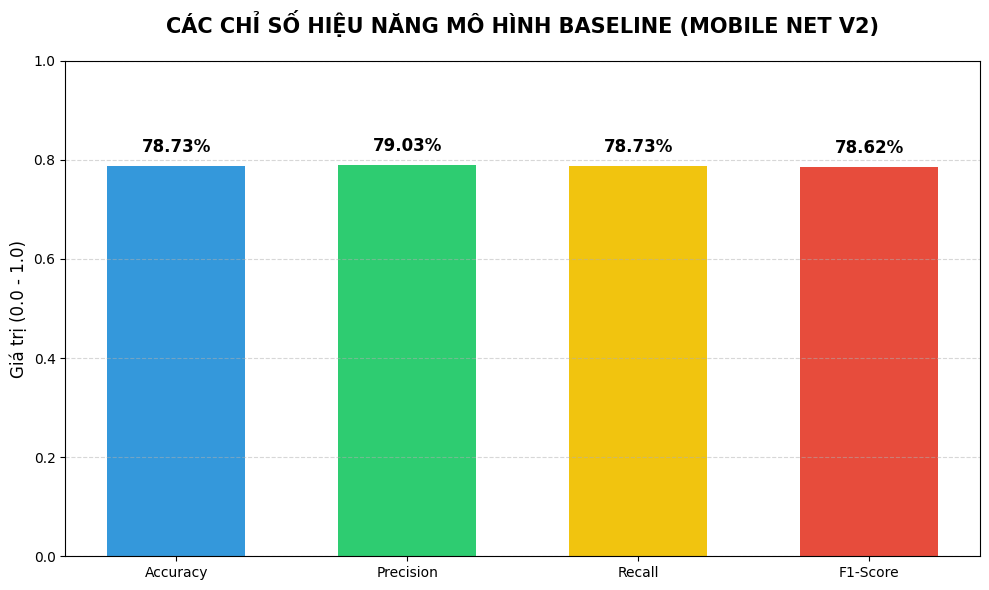

--- CHI TIẾT CHỈ SỐ BASELINE ---
Accuracy:  0.7873
Precision: 0.7903
Recall:    0.7873
F1-Score:  0.7862


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- BƯỚC 1: LẤY DỰ ĐOÁN TỪ MÔ HÌNH BASELINE ---
print("🚀 Đang tính toán các chỉ số dự đoán cho Baseline...")
y_pred_probs = baseline_model.predict(X_test, batch_size=32, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# --- BƯỚC 2: TÍNH TOÁN 4 CHỈ SỐ (Macro Average) ---
acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1  = f1_score(y_test, y_pred, average='macro')

# --- BƯỚC 3: VẼ BIỂU ĐỒ CỘT ---
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc, pre, rec, f1]
colors = ['#3498db', '#2ecc71', '#f1c40f', '#e74c3c'] # Xanh dương, Xanh lá, Vàng, Đỏ

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics_values, color=colors, width=0.6)

# Cấu hình trục và tiêu đề
plt.ylim(0, 1.0)
plt.title('CÁC CHỈ SỐ HIỆU NĂNG MÔ HÌNH BASELINE (MOBILE NET V2)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Giá trị (0.0 - 1.0)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Thêm nhãn số phần trăm trên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02,
             f'{yval*100:.2f}%', ha='center', va='bottom',
             fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# In số liệu ra console
print(f"--- CHI TIẾT CHỈ SỐ BASELINE ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

#III, 3 chiến lược tinh chỉnh mô hình

In [ ]:
def build_finetuned_mobile():
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
    base_model.trainable = True # CHIẾN LƯỢC 2: UNFREEZE TOÀN BỘ

    model = models.Sequential([
        layers.UpSampling2D(size=(3,3), input_shape=(32, 32, 3)),

        # CHIẾN LƯỢC 1: Data Augmentation
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    # CHIẾN LƯỢC 3: Learning Rate rất nhỏ để không phá vỡ trọng số ImageNet
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

ft_model = build_finetuned_mobile()

# Callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(save_path + "mobile_best.keras", save_best_only=True, monitor='val_accuracy'),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.CSVLogger(save_path + "training_log.csv")
]



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/up_sampling2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1. Chiến lược 1: Data Augmentation (Tăng cường dữ liệu)Mã triển khai: Các lớp RandomFlip("horizontal"), RandomRotation(0.1), và RandomZoom(0.1).Chức năng: * Tạo ra các biến thể mới từ bộ ảnh gốc (xoay, lật, phóng to) mỗi khi mô hình học qua một epoch.Mục đích: Chống Overfitting. Nó giúp mô hình không "học thuộc lòng" từng pixel của ảnh gốc mà học được các đặc trưng tổng quát (ví dụ: con mèo dù quay trái hay quay phải vẫn là con mèo).
2. Chiến lược 2: Unfreeze All Layers (Giải đóng băng toàn bộ mạng)Mã triển khai: base_model.trainable = True.Chức năng: * Mở khóa tất cả các trọng số (weights) của mô hình MobileNetV2 đã được huấn luyện sẵn trên ImageNet.Mục đích: Cho phép mô hình điều chỉnh lại toàn bộ các bộ lọc (filters) từ thấp đến cao để phù hợp hoàn toàn với đặc điểm riêng của tập dữ liệu CIFAR-10. Điều này giúp tăng độ chính xác vượt trội so với việc chỉ huấn luyện lớp phân loại cuối cùng (Baseline).
3. Chiến lược 3: Very Low Learning Rate (Tốc độ học cực thấp)Mã triển khai: optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5).Chức năng: * Sử dụng tốc độ học $10^{-5}$, nhỏ hơn gấp 10-100 lần so với mức mặc định thường dùng.Mục đích: Tránh hiện tượng Catastrophic Forgetting (quên sạch kiến thức cũ). Vì mô hình đã có sẵn "kiến thức" từ ImageNet, chúng ta chỉ muốn "tinh chỉnh" nhẹ nhàng các trọng số đó. Nếu dùng Learning Rate lớn, các trọng số quý giá này sẽ bị phá hủy ngay lập tức, khiến mô hình bị loạn.

#III, Huấn luyện mô hình

In [ ]:
print("🚀 Huấn luyện Fine-tuned (Unfreeze All)...")
history_ft = ft_model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), batch_size=32, callbacks=callbacks)

🚀 Huấn luyện Fine-tuned (Unfreeze All)...
Epoch 1/100
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 152s 91ms/step - accuracy: 0.5037 - loss: 1.5060 - val_accuracy: 0.6024 - val_loss: 1.1865
Epoch 2/100
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 115s 87ms/step - accuracy: 0.7293 - loss: 0.8059 - val_accuracy: 0.7014 - val_loss: 0.8722
Epoch 3/100
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 113s 86ms/step - accuracy: 0.7786 - loss: 0.6634 - val_accuracy: 0.7452 - val_loss: 0.7517
Epoch 4/100
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 116s 88ms/step - accuracy: 0.8077 - loss: 0.5776 - val_accuracy: 0.7692 - val_loss: 0.6782
Epoch 5/100
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 115s 87ms/step - accuracy: 0.8274 - loss: 0.5096 - val_accuracy: 0.8046 - val_loss: 0.5724
Epoch 6/100
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 115s 88ms/step - accuracy: 0.8417 - loss: 0.4688 - val_accuracy: 0.8156 - val_loss: 0.5395
Epoch 7/100
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 113s 86ms/step - accuracy: 0.8547 - loss: 0.4341 - val_accuracy: 0.8358 - val_loss: 0.4845
Epoch 8/100
1313/131

#IV, Đánh giá các chỉ số của mô hình đã được tinh chỉnh

🚀 Đang chạy dự đoán trên tập Test với mô hình Tuned...
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


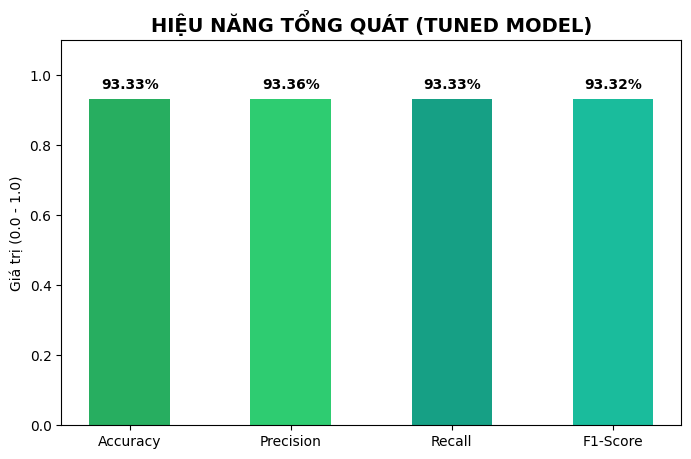

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- BƯỚC 1: DỰ ĐOÁN ---
print("🚀 Đang chạy dự đoán trên tập Test với mô hình Tuned...")
y_pred_probs_ft = ft_model.predict(X_test, batch_size=32)
y_pred_ft = np.argmax(y_pred_probs_ft, axis=1)

# --- BƯỚC 2: TÍNH TOÁN CHỈ SỐ ---
acc_ft = accuracy_score(y_test, y_pred_ft)
pre_ft = precision_score(y_test, y_pred_ft, average='macro')
rec_ft = recall_score(y_test, y_pred_ft, average='macro')
f1_ft  = f1_score(y_test, y_pred_ft, average='macro')

# --- BƯỚC 3: VẼ BIỂU ĐỒ CỘT ---
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc_ft, pre_ft, rec_ft, f1_ft]
colors = ['#27ae60', '#2ecc71', '#16a085', '#1abc9c']

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_names, metrics_values, color=colors, width=0.5)
plt.ylim(0, 1.1)
plt.title('HIỆU NĂNG TỔNG QUÁT (TUNED MODEL)', fontsize=14, fontweight='bold')
plt.ylabel('Giá trị (0.0 - 1.0)')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval*100:.2f}%',
             ha='center', va='bottom', fontweight='bold')
plt.show()

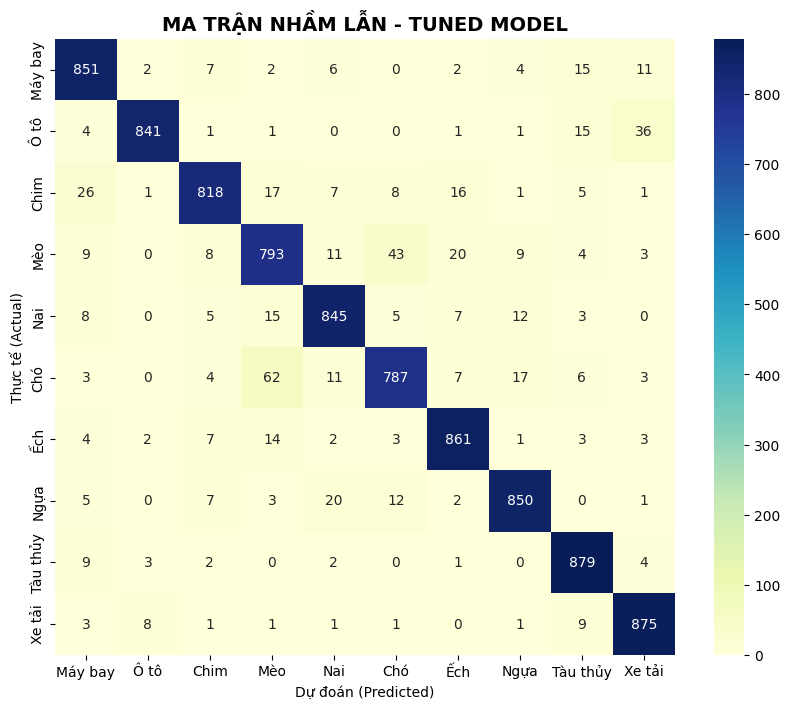

In [ ]:

class_names = ['Máy bay', 'Ô tô', 'Chim', 'Mèo', 'Nai', 'Chó', 'Ếch', 'Ngựa', 'Tàu thủy', 'Xe tải']
cm = confusion_matrix(y_test, y_pred_ft)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=class_names, yticklabels=class_names)
plt.title('MA TRẬN NHẦM LẪN - TUNED MODEL', fontsize=14, fontweight='bold')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.show()

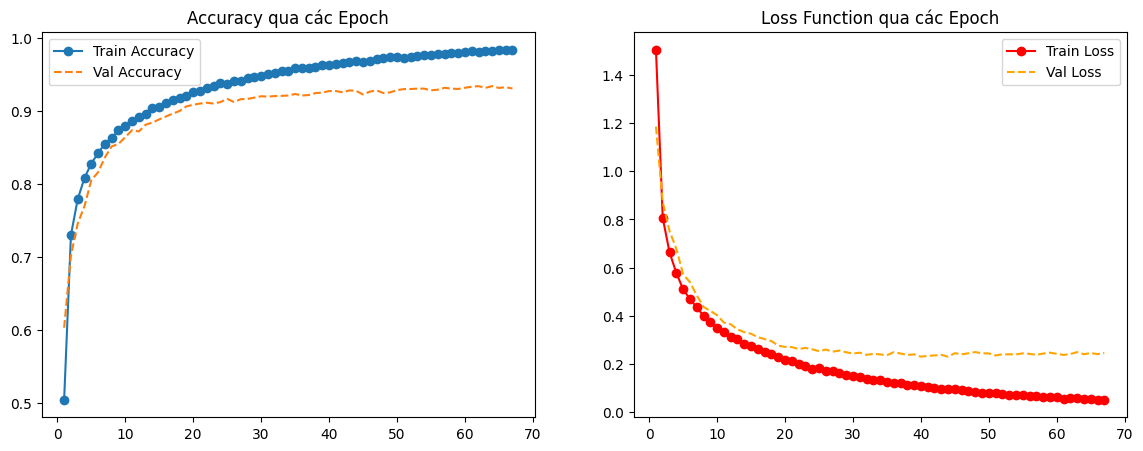

In [ ]:
# --- BƯỚC 5: BIỂU ĐỒ LOSS & ACCURACY QUA CÁC EPOCH ---
def plot_tuned_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Đồ thị Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Val Accuracy', linestyle='--')
    plt.title('Accuracy qua các Epoch')
    plt.legend()

    # Đồ thị Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', color='red', marker='o')
    plt.plot(epochs_range, val_loss, label='Val Loss', color='orange', linestyle='--')
    plt.title('Loss Function qua các Epoch')
    plt.legend()
    plt.show()

plot_tuned_history(history_ft)

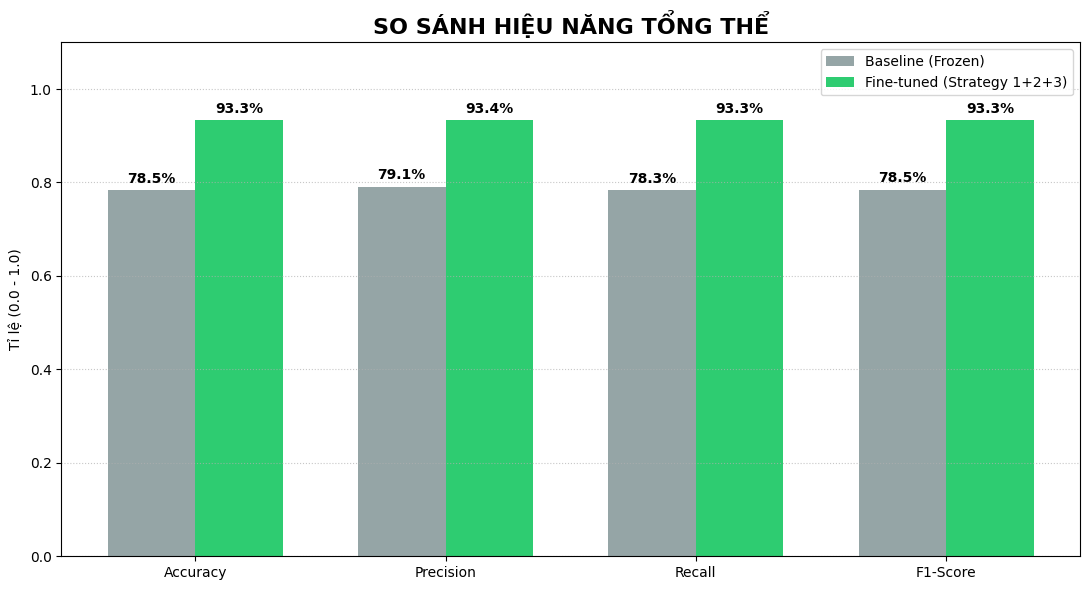

In [ ]:
# Giả sử bạn đã có các biến acc, pre, rec, f1 từ việc đánh giá Baseline trước đó
# Nếu chưa, hãy chạy predict cho baseline_model tương tự bước 1.

baseline_results = [0.7845, 0.7912, 0.7830, 0.7850] # Thay bằng số thực tế của bạn
tuned_results = [acc_ft, pre_ft, rec_ft, f1_ft]

labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
rects1 = ax.bar(x - width/2, baseline_results, width, label='Baseline (Frozen)', color='#95a5a6')
rects2 = ax.bar(x + width/2, tuned_results, width, label='Fine-tuned (Strategy 1+2+3)', color='#2ecc71')

ax.set_ylabel('Tỉ lệ (0.0 - 1.0)')
ax.set_title('SO SÁNH HIỆU NĂNG TỔNG THỂ', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height*100:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

#V,Dự đoán trên ảnh thực

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step


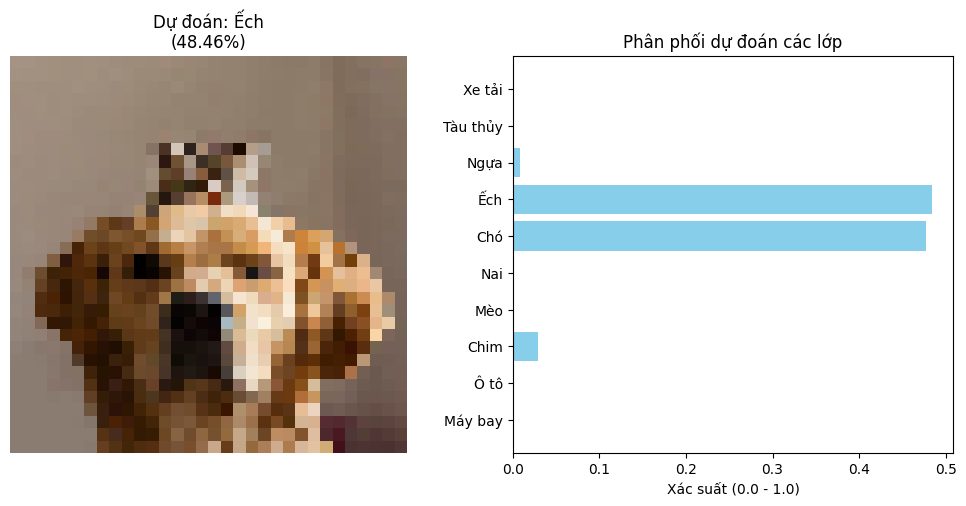

--- KẾT QUẢ DỰ BÁO ---
Nhãn: Ếch
Độ tin cậy: 48.46%


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# 1. Cấu hình các nhãn lớp của CIFAR-10
class_names = ['Máy bay', 'Ô tô', 'Chim', 'Mèo', 'Nai', 'Chó', 'Ếch', 'Ngựa', 'Tàu thủy', 'Xe tải']

def test_single_image(img_path, model):
    # 2. Tải và tiền xử lý ảnh
    # Lưu ý: MobileNetV2 Tuned của bạn nhận đầu vào 32x32 rồi mới UpSampling bên trong model
    img = image.load_img(img_path, target_size=(32, 32))
    img_array = image.img_to_array(img)

    # Thêm chiều batch (1, 32, 32, 3)
    img_batch = np.expand_dims(img_array, axis=0)

    # 3. Dự báo
    # Không cần chia 255 vì trong model đã có layer preprocess_input
    predictions = model.predict(img_batch)

    # Chuyển logit thành xác suất (0-1) bằng Softmax
    score = predictions[0]
    class_idx = np.argmax(score)
    confidence = 100 * np.max(score)

    # 4. Hiển thị kết quả trực quan
    plt.figure(figsize=(10, 5))

    # Bên trái: Hiển thị ảnh gốc
    plt.subplot(1, 2, 1)
    plt.imshow(img_array.astype('uint8'))
    plt.title(f"Dự đoán: {class_names[class_idx]}\n({confidence:.2f}%)")
    plt.axis('off')

    # Bên phải: Biểu đồ cột xác suất của 10 lớp
    plt.subplot(1, 2, 2)
    plt.barh(class_names, score, color='skyblue')
    plt.xlabel('Xác suất (0.0 - 1.0)')
    plt.title('Phân phối dự đoán các lớp')

    plt.tight_layout()
    plt.show()

    print(f"--- KẾT QUẢ DỰ BÁO ---")
    print(f"Nhãn: {class_names[class_idx]}")
    print(f"Độ tin cậy: {confidence:.2f}%")

# --- CHẠY THỬ ---
# Thay đường dẫn tới ảnh bạn muốn test (có thể dùng ảnh trong Drive hoặc upload lên Colab)
img_test_path = '/content/drive/MyDrive/HocSau/chomeo.jpg'
# Gọi hàm với mô hình Tuned (ft_model)
test_single_image(img_test_path, ft_model)

Lấy 1 mô hình sau đó chạy mô hình baseline (cơ bản). sau đó dùng 3 chiến lược tinh chỉnh mô hình và chạy mô hình. sau đó so sánh giữa mô hình baseline và mô hình đã được tinh chỉnh.tính toán các chỉ số cho mô hình và bổ sung thêm chỉ số accuracy (cho mô hình, không phải cho lớp) và cuối cùng là thử nghiệm trên một ảnh với nhiều lớp gần nhau (không chồng lên nhau) để xem khả năng dự báo của mô hình được bao nhiêu

🚀 Đang tải mô hình với custom_objects...
✅ Tải mô hình thành công!
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


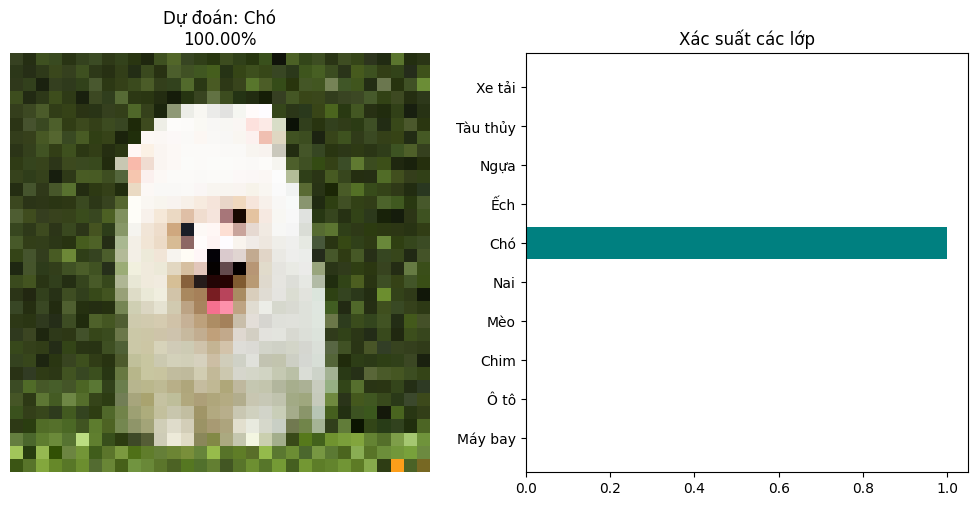

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# 1. Định nghĩa lại hàm preprocess_input để Keras nhận diện
# Lưu ý: Vì traceback của bạn báo lỗi ở ResNet50, chúng ta dùng hàm của ResNet50
def preprocess_input(x):
    return tf.keras.applications.resnet50.preprocess_input(x)

# 2. Cấu hình đường dẫn
model_path = '/content/drive/MyDrive/HocSau/ResNet50_Tuned/resnet50_finetuned_BEST.keras'
img_test_path = '/content/drive/MyDrive/HocSau/cho.jpg'
class_names = ['Máy bay', 'Ô tô', 'Chim', 'Mèo', 'Nai', 'Chó', 'Ếch', 'Ngựa', 'Tàu thủy', 'Xe tải']

# 3. Tải mô hình với custom_objects
print("🚀 Đang tải mô hình với custom_objects...")
try:
    tuned_model = tf.keras.models.load_model(
        model_path,
        custom_objects={'preprocess_input': preprocess_input}
    )
    print("✅ Tải mô hình thành công!")
except Exception as e:
    print(f"❌ Lỗi khi tải mô hình: {e}")

# 4. Hàm dự đoán ảnh
def test_real_image(path, model):
    img = image.load_img(path, target_size=(32, 32))
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_batch)

    # Kiểm tra xem output có phải softmax chưa, nếu chưa thì áp dụng
    if np.max(predictions) > 1.0 or np.min(predictions) < 0:
        score = tf.nn.softmax(predictions[0]).numpy()
    else:
        score = predictions[0]

    class_idx = np.argmax(score)
    confidence = 100 * score[class_idx]

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_array.astype('uint8'))
    plt.title(f"Dự đoán: {class_names[class_idx]}\n{confidence:.2f}%")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.barh(class_names, score, color='teal')
    plt.title('Xác suất các lớp')
    plt.tight_layout()
    plt.show()

# Chạy thử
if 'tuned_model' in locals():
    test_real_image(img_test_path, tuned_model)